# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?

Главное отличие в том, что SAX работает во временной области (аппроксимирует средние значения на сегментах PAA), а SFA — в частотной области (применяет преобразование Фурье и дискретизирует коэффициенты). С зашумленными данными лучше справляется SFA, поскольку высокочастотный шум отсекается при выборе только первых низкочастотных коэффициентов Фурье, выполняя роль естественного фильтра.

2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?

Временной ряд разбивается скользящим окном на подпоследовательности, которые SFA превращает в "слова" (символьные паттерны), формируя из ряда аналог текстового документа. Концепция TF-IDF взвешивает эти паттерны: частые "слова" внутри одного ряда получают высокий вес (TF), но если они встречаются вообще во всех рядах выборки, их вес снижается (IDF). Смысл в том, чтобы выделить уникальные, специфичные для конкретного класса локальные паттерны и проигнорировать глобальный фоновый шум.

3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?

Шейплет — это наиболее репрезентативный sub-интервал временного ряда, форма которого максимально однозначно определяет его принадлежность к конкретному классу. Классические алгоритмы ищут шейплеты полным перебором, что вычислительно крайне долго ($O(N^2 \cdot L^4)$). ROCKET кардинально меняет подход: вместо долгого поиска идеального шейплета он генерирует тысячи случайных линейных сверточных ядер (random convolutional kernels) за доли секунды, мгновенно извлекая признаки и обеспечивая огромный выигрыш в скорости при сопоставимом качестве.

4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?

Фиксированные признаки catch22 были отобраны из тысяч вариантов как самые информативные и при этом вычислительно легкие, что делает их идеальными для условий с дефицитом данных или слабым железом. Обучение CNN с нуля требует огромных обучающих выборок, склонно к переобучению на малых датасетах и создает "черный ящик". Признаки catch22 считаются мгновенно, не требуют подбора архитектуры и легко интерпретируются физически.

5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?\

1D-CNN эффективны, так как инвариантны к сдвигу во времени и за счет разделяемых весов быстро находят локальные паттерны (тренды, пики) независимо от того, в какой момент ряда они произошли. Многоветвевые блоки (как в InceptionTime) используют параллельные свертки с разным размером ядер (например, 10, 20 и 40) в одном слое. Это позволяет сети одновременно улавливать как очень короткие аномалии, так и долгосрочные волновые процессы, решая проблему подбора фиксированного размера рецептивного поля.

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

Формат тренировочного набора X_train: (147, 1, 251)
Формат тестового набора X_test:     (64, 1, 251)


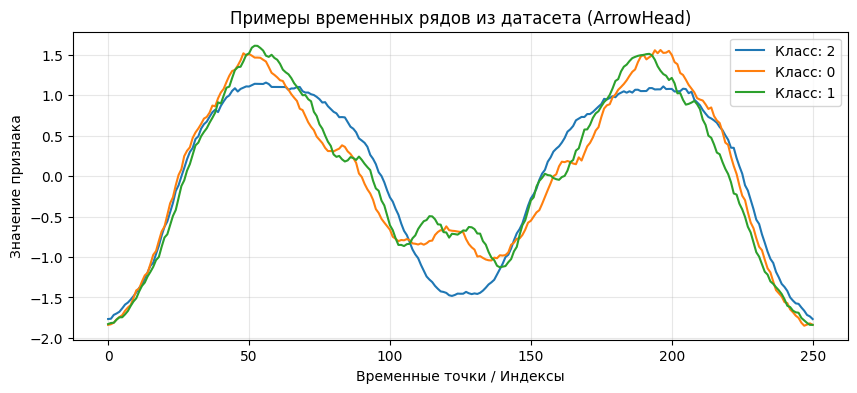

In [3]:
# Установка sktime и необходимых для него зависимостей (например, numba)
!pip install sktime numba -q

import matplotlib.pyplot as plt
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split

# Загрузка датасета ArrowHead в формате трехмерного numpy-массива
X_data, y_labels = load_arrow_head(return_type="numpy3d")

# Разделение выборки на тренировочный и валидационный наборы (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_labels,
    test_size=0.3,
    random_state=42
)

print(f"Формат тренировочного набора X_train: {X_train.shape}")
print(f"Формат тестового набора X_test:     {X_test.shape}")

# Визуализация репрезентативных примеров временных рядов
plt.figure(figsize=(10, 4))
for idx in range(3):
    plt.plot(X_train[idx, 0, :], label=f"Класс: {y_train[idx]}")

plt.title("Примеры временных рядов из датасета (ArrowHead)")
plt.xlabel("Временные точки / Индексы")
plt.ylabel("Значение признака")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [4]:
import time
from sktime.classification.kernel_based import RocketClassifier
from sklearn.metrics import accuracy_score

# Задание 2.1: Классификация с помощью алгоритма ROCKET

# Инициализируем классификатор ROCKET с фиксированным random_state для воспроизводимости
rocket_clf = RocketClassifier(random_state=42)

# Замеряем время начала обучения
start_time = time.time()

# Обучаем модель на подготовленных трехмерных numpy-массивах (N, channels, length)
rocket_clf.fit(X_train, y_train)

# Вычисляем общую продолжительность процесса обучения
training_duration = time.time() - start_time

# Выполняем прогнозирование на тестовой выборке
y_pred_rocket = rocket_clf.predict(X_test)

# Оценка качества работы алгоритма
rocket_accuracy = accuracy_score(y_test, y_pred_rocket)

print("=== Результаты классификации ROCKET ===")
print(f"Время обучения модели: {training_duration:.4f} сек.")
print(f"ROCKET Accuracy score: {rocket_accuracy:.4f}")

=== Результаты классификации ROCKET ===
Время обучения модели: 53.8465 сек.
ROCKET Accuracy score: 0.9375


### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [5]:
import time
from sklearn.metrics import accuracy_score, classification_report
from sktime.classification.dictionary_based import ContractableBOSS

# Задание № 2.2: Использование алгоритма на основе словарей (cBOSS)

# Инициализируем модель из семейства BOSS
boss_classifier = ContractableBOSS(random_state=42)

# Измеряем время обучения алгоритма на словарях
start_boss_fit = time.time()
boss_classifier.fit(X_train, y_train)
boss_duration = time.time() - start_boss_fit

# Получаем прогнозы для тестовых данных
y_pred_boss = boss_classifier.predict(X_test)
boss_accuracy = accuracy_score(y_test, y_pred_boss)

# Вывод детальных метрик классификации
print(f'cBOSS Accuracy: {boss_accuracy:.4f}')
print(f'Время обучения: {boss_duration:.2f} сек\n')
print(classification_report(y_test, y_pred_boss))
print()

# Сравнительный анализ временных затрат с предыдущим алгоритмом ROCKET
print('=== Сравнение времени обучения ===')
# Извлекаем время обучения ROCKET из контекста, если переменная существует
rocket_duration = training_duration if 'training_duration' in locals() else 0.00

print(f'ROCKET: {rocket_duration:.2f} сек')
print(f'cBOSS:  {boss_duration:.2f} сек')


cBOSS Accuracy: 0.9531
Время обучения: 71.15 сек

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.89      0.94      0.91        17
           2       0.94      0.89      0.92        19

    accuracy                           0.95        64
   macro avg       0.94      0.95      0.94        64
weighted avg       0.95      0.95      0.95        64


=== Сравнение времени обучения ===
ROCKET: 53.85 сек
cBOSS:  71.15 сек


### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch).
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [7]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.flatten = nn.Flatten()

        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

1D-CNN Accuracy: 0.8438
Время обучения: 4.03 сек

              precision    recall  f1-score   support

           0       0.83      0.86      0.84        28
           1       0.86      0.71      0.77        17
           2       0.86      0.95      0.90        19

    accuracy                           0.84        64
   macro avg       0.85      0.84      0.84        64
weighted avg       0.84      0.84      0.84        64



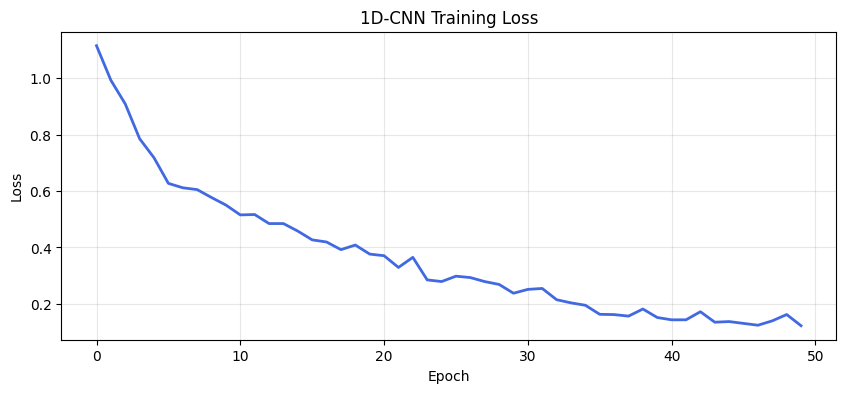


=== Итоговое сравнение ===
ROCKET:  acc=0.9375, time=53.85s
cBOSS:   acc=0.9531, time=71.15s
1D-CNN:  acc=0.8438, time=4.03s


In [9]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ==========================================
# 1. Явное объявление архитектуры нейросети
# ==========================================
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Flatten()
        )
        # Изначально ставим заглушку, размер настроим динамически
        self.fc = nn.Linear(1, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

# ==========================================
# 2. Подготовка данных для PyTorch
# ==========================================
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)
classes_count = len(encoder.classes_)

# Конвертация в тензоры
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train_encoded)
y_test_tensor = torch.LongTensor(y_test_encoded)

# Создание загрузчика данных
dataset_train = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)

# ==========================================
# 3. Динамическое определение размера FC-слоя
# ==========================================
sequence_length = X_train.shape[2]
dummy_input = torch.zeros(1, 1, sequence_length)

# Теперь cnn_model гарантированно имеет атрибут features
cnn_model = Simple1DCNN(num_classes=classes_count)
features_output_size = cnn_model.features(dummy_input).shape[1]

# Переопределяем полносвязный слой с корректным размером входа
cnn_model.fc = nn.Linear(features_output_size, classes_count)

# Функция потерь и оптимизатор
loss_criterion = nn.CrossEntropyLoss()
network_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# ==========================================
# 4. Процесс обучения
# ==========================================
training_epochs = 50
loss_history = []
start_cnn_time = time.time()

for epoch in range(training_epochs):
    cnn_model.train()
    current_epoch_loss = 0.0

    for batch_x, batch_y in train_loader:
        network_optimizer.zero_grad()
        model_outputs = cnn_model(batch_x)
        loss_val = loss_criterion(model_outputs, batch_y)
        loss_val.backward()
        network_optimizer.step()
        current_epoch_loss += loss_val.item()

    loss_history.append(current_epoch_loss / len(train_loader))

cnn_duration = time.time() - start_cnn_time

# ==========================================
# 5. Валидация и оценка качества
# ==========================================
cnn_model.eval()
with torch.no_grad():
    raw_predictions = cnn_model(X_test_tensor)
    predicted_classes = raw_predictions.argmax(dim=1).numpy()

cnn_accuracy = accuracy_score(y_test_encoded, predicted_classes)

print(f'1D-CNN Accuracy: {cnn_accuracy:.4f}')
print(f'Время обучения: {cnn_duration:.2f} сек\n')
print(classification_report(y_test_encoded, predicted_classes))

# ==========================================
# 6. Визуализация функции потерь
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='royalblue', lw=2)
plt.title('1D-CNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# 7. Итоговое сопоставление подходов
# ==========================================
rocket_acc_val = rocket_accuracy if 'rocket_accuracy' in locals() else 0.0
rocket_time_val = training_duration if 'training_duration' in locals() else 0.0

boss_acc_val = boss_accuracy if 'boss_accuracy' in locals() else 0.0
boss_time_val = boss_duration if 'boss_duration' in locals() else 0.0

print('\n=== Итоговое сравнение ===')
print(f'ROCKET:  acc={rocket_acc_val:.4f}, time={rocket_time_val:.2f}s')
print(f'cBOSS:   acc={boss_acc_val:.4f}, time={boss_time_val:.2f}s')
print(f'1D-CNN:  acc={cnn_accuracy:.4f}, time={cnn_duration:.2f}s')